In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
import matplotlib.pyplot as plt

Load Dataset


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Normalize Dataset


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

Build ANN Model

In [ ]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9229 - loss: 0.2676 - val_accuracy: 0.9592 - val_loss: 0.1373
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9644 - loss: 0.1143 - val_accuracy: 0.9693 - val_loss: 0.1074
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9762 - loss: 0.0775 - val_accuracy: 0.9742 - val_loss: 0.0891
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9813 - loss: 0.0580 - val_accuracy: 0.9740 - val_loss: 0.0874
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9854 - loss: 0.0452 - val_accuracy: 0.9739 - val_loss: 0.0883
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9886 - loss: 0.0358 - val_accuracy: 0.9763 - val_loss: 0.0841
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9914 - loss: 0.0275 - val_accuracy: 0.9743 - val_loss: 0.0948
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9915 - loss: 0.0261 - 

Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Accuracy:", accuracy)

Prediction

In [13]:
prediction = model.predict(x_test[:1])

print("Predicted Digit:", prediction.argmax())
print("Actual Digit:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted Digit: 7
Actual Digit: 7


Display Image

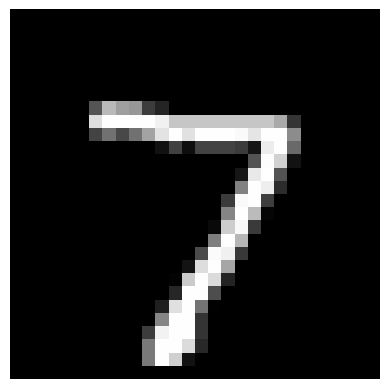

In [14]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.axis('off')
plt.show()

Accuracy Graph

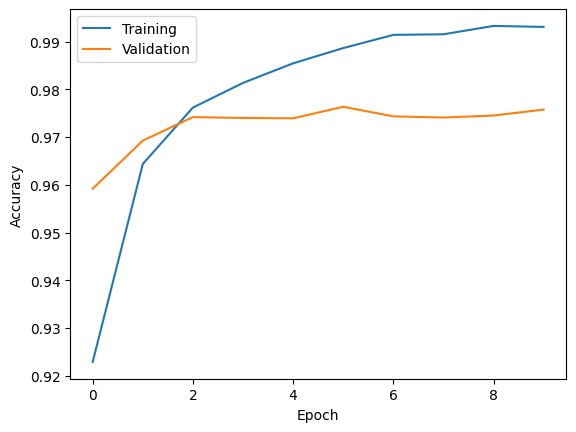

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])
plt.show()